# MNIST Handwritten Digit Classification

This notebook demonstrates how to build a simple neural network for classifying handwritten digits (0-9) from the MNIST dataset using TensorFlow and Keras. The MNIST dataset contains 70,000 grayscale images of handwritten digits, each 28x28 pixels.

## Overview

This project covers:
- Loading and exploring the MNIST dataset
- Data preprocessing (normalization)
- Building a neural network model
- Training and evaluating the model
- Making predictions and visualizing results

## Requirements

Make sure you have the following packages installed:
- TensorFlow 2.x
- NumPy
- Matplotlib
- Scikit-learn (for confusion matrix)

You can install them using: `pip install -r requirements.txt`

In [1]:
!pip install tensorflow matplotlib numpy

  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-1-py2.py3-none-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.34.0-cp310-abi3-macosx_10_9_universal2.whl.metadata (595 bytes)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached keras-3.13.2-py3-none-any.whl.metadata (6.3 kB)
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached namex-0.1.0-py3-

In [2]:
!pip install pydot graphviz

  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
Using cached graphviz-0.21-py3-none-any.whl (47 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [graphviz]


## Setup and Dependencies

Install the required packages if not already installed. This step ensures all necessary libraries are available.

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

## Loading the MNIST Dataset

The MNIST dataset is a classic dataset for handwritten digit recognition. It consists of 60,000 training images and 10,000 test images of digits from 0 to 9.

In [4]:
mnist = tf.keras.datasets.mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


## Data Exploration and Visualization

Let's explore the dataset by visualizing some sample images and understanding the data structure.

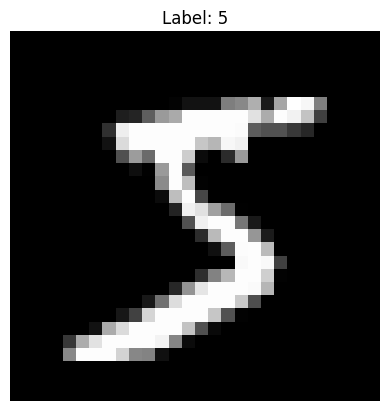

In [5]:
#visualize images
plt.imshow(x_train[0], cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.axis("off")
plt.show()

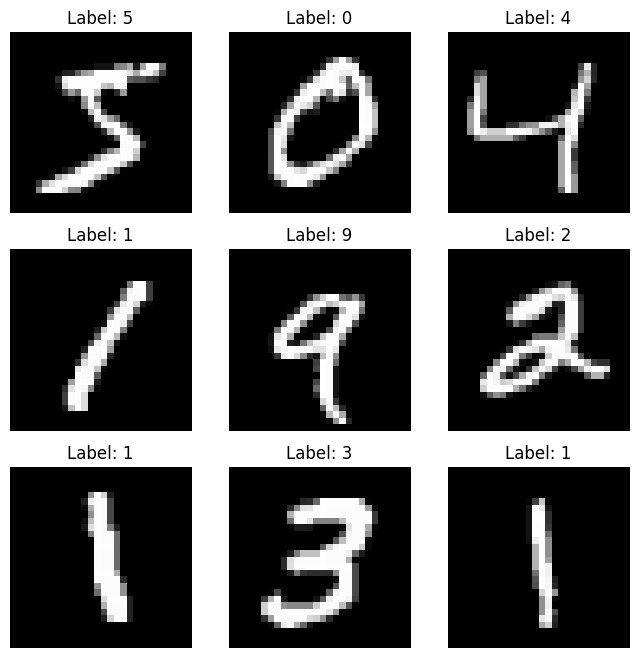

In [30]:
plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.show()

In [6]:
print(x_train.shape)
print(y_train.shape)

(60000, 28, 28)
(60000,)


In [7]:
print(x_train[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 18

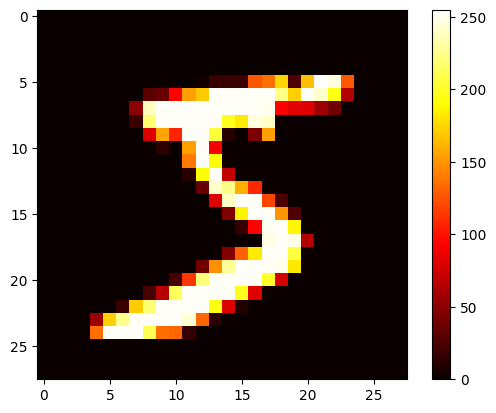

In [8]:
plt.imshow(x_train[0], cmap='hot')
plt.colorbar()
plt.show()


In [9]:
#NORMALIZING THE DATASET
x_train = x_train / 255.0
x_test = x_test / 255.0

## Data Preprocessing

Neural networks perform better with normalized data. We scale the pixel values from 0-255 to 0-1.

In [10]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

/Users/bhargavparekh/Documents/MINSTAT_Classification/.conda/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## Building the Neural Network Model

We create a simple feedforward neural network with:
- An input layer that flattens the 28x28 images into 784 pixels
- A hidden layer with 128 neurons and ReLU activation
- An output layer with 10 neurons (one for each digit) and softmax activation

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

## Model Visualization

Let's visualize the architecture of our neural network.

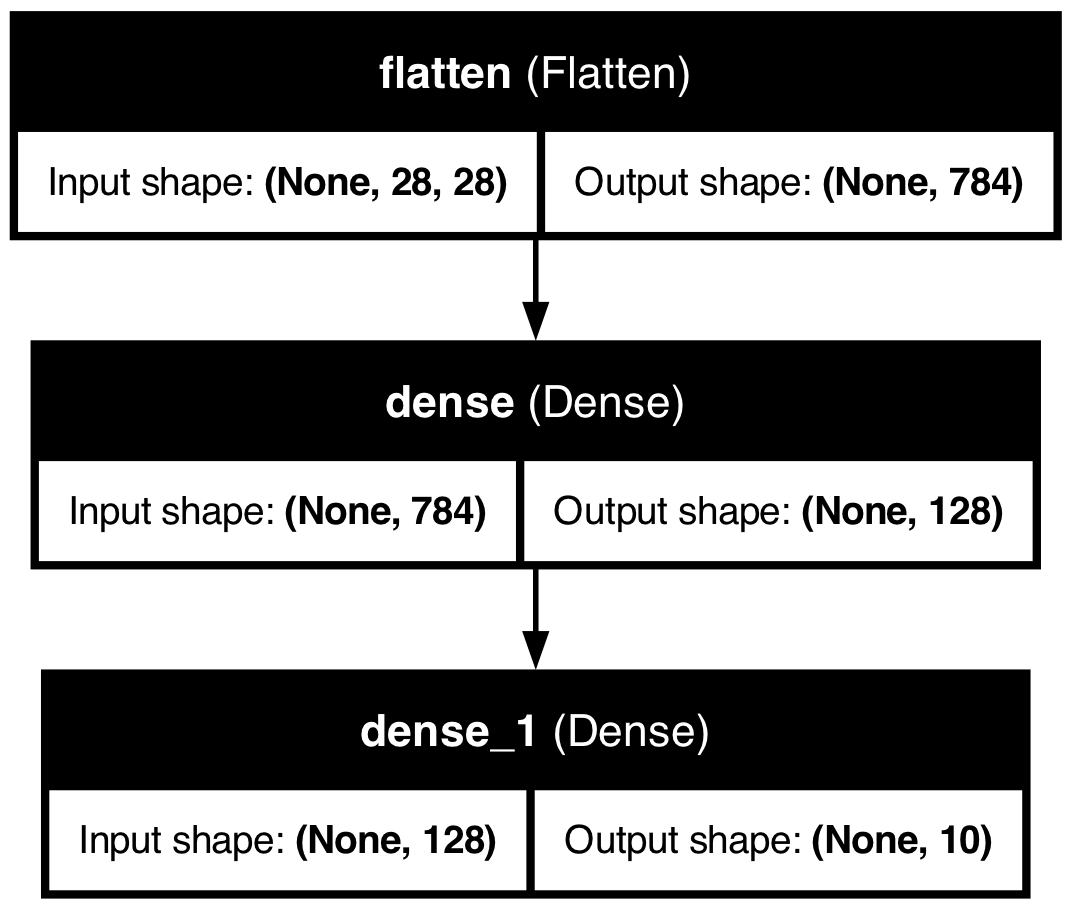

In [12]:
from tensorflow.keras.utils import plot_model

plot_model(
    model,
    to_file="neural_network.png",
    show_shapes=True,
    show_layer_names=True
)

In [13]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Training the Model

We compile the model with:
- Adam optimizer for efficient gradient descent
- Sparse categorical crossentropy loss (suitable for integer labels)
- Accuracy as the evaluation metric

Then train the model for 30 epochs with validation on the test set.

In [14]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_data=(x_test, y_test)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9255 - loss: 0.2623 - val_accuracy: 0.9578 - val_loss: 0.1433
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9653 - loss: 0.1174 - val_accuracy: 0.9667 - val_loss: 0.1094
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9760 - loss: 0.0811 - val_accuracy: 0.9738 - val_loss: 0.0861
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9812 - loss: 0.0615 - val_accuracy: 0.9735 - val_loss: 0.0847
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 979us/step - accuracy: 0.9854 - loss: 0.0468 - val_accuracy: 0.9792 - val_loss: 0.0716


## Training Results and Visualization

After training, we plot the loss and accuracy curves for both training and validation sets to monitor overfitting and convergence.

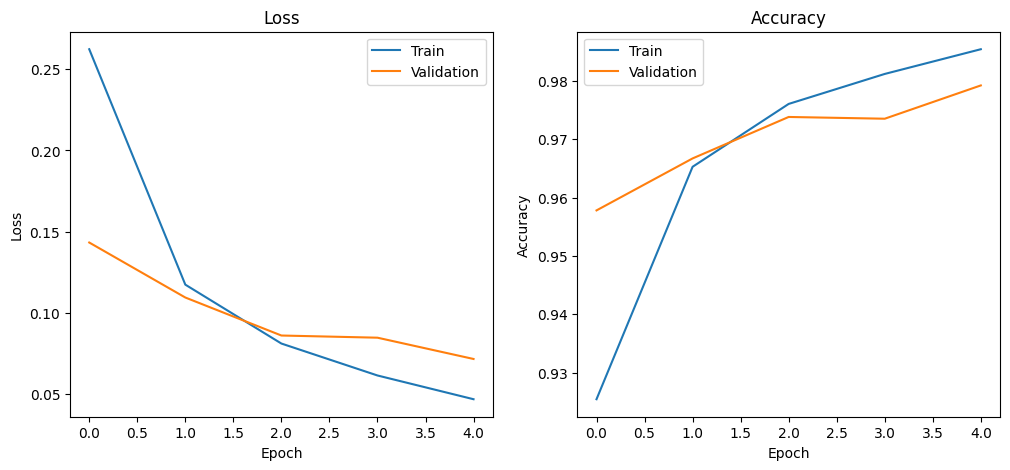

In [15]:
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.show()

In [16]:
#Test Model
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 419us/step - accuracy: 0.9792 - loss: 0.0716
Test Accuracy: 0.979200005531311


## Model Evaluation

Evaluate the trained model on the test set to get the final accuracy and loss.

In [17]:
#Making a Prediction
predictions = model.predict(x_test)

print(np.argmax(predictions[0]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 343us/step
7


## Making Predictions

Use the trained model to make predictions on test images. The model outputs probabilities for each digit class.

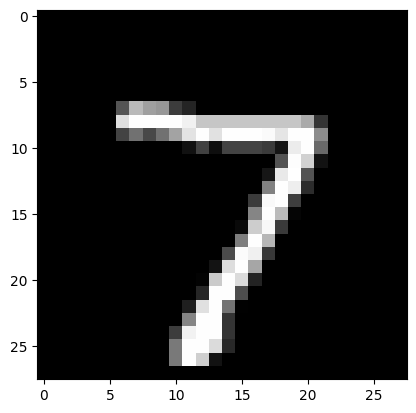

In [18]:
#image to show
plt.imshow(x_test[0], cmap='gray')
plt.show()

In [19]:
import numpy as np

predictions = model.predict(x_test)

y_pred = np.argmax(predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 313us/step


In [20]:
!pip install scikit-learn

  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 23.9 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 19.7 MB/s  0:00:01m0:00:0100:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]


In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 970    0    1    2    0    0    0    1    5    1]
 [   0 1123    2    2    0    1    2    0    5    0]
 [   3    0 1007    1    1    1    3    5    9    2]
 [   0    0    1  989    0    5    0    2    7    6]
 [   2    0    5    1  951    0    3    1    1   18]
 [   2    0    0    7    1  868    3    2    6    3]
 [   3    3    0    1    6    6  936    0    3    0]
 [   1    5    7    4    0    0    0 1002    4    5]
 [   2    0    1    3    1    1    2    2  960    2]
 [   4    4    0    2    5    2    0    3    3  986]]


## Confusion Matrix Analysis

A confusion matrix shows the model's predictions versus the actual labels. It helps identify which digits are most commonly misclassified.

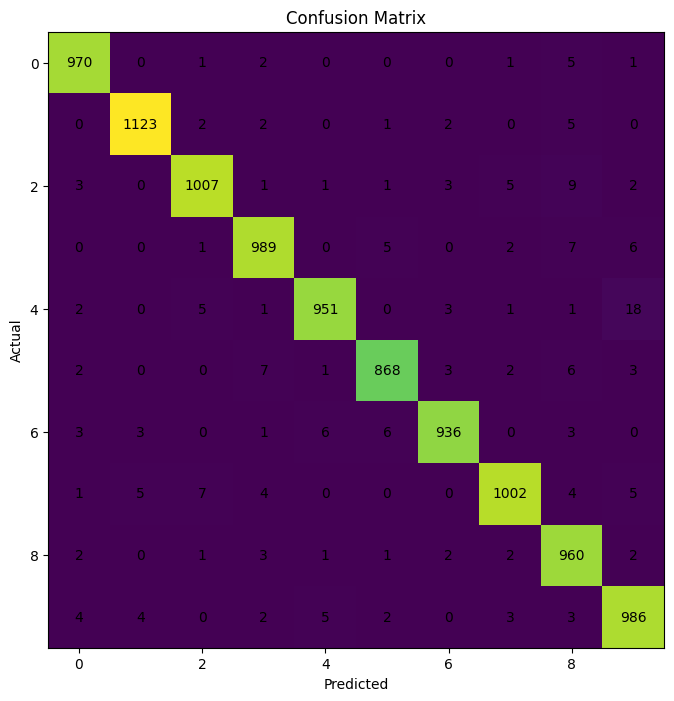

In [22]:
plt.figure(figsize=(8,8))
plt.imshow(cm)

for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()